In [120]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from scipy.fft import fft, ifft
from tkinter import Tk, simpledialog
import os

In [121]:
# Load data from CSV file
csv_filename = 'JCP 2_27.csv' #this is the only line that needs to be modified
data = pd.read_csv(csv_filename, header=None)
x = data.iloc[:, 0].values
y = data.iloc[:, 1].values

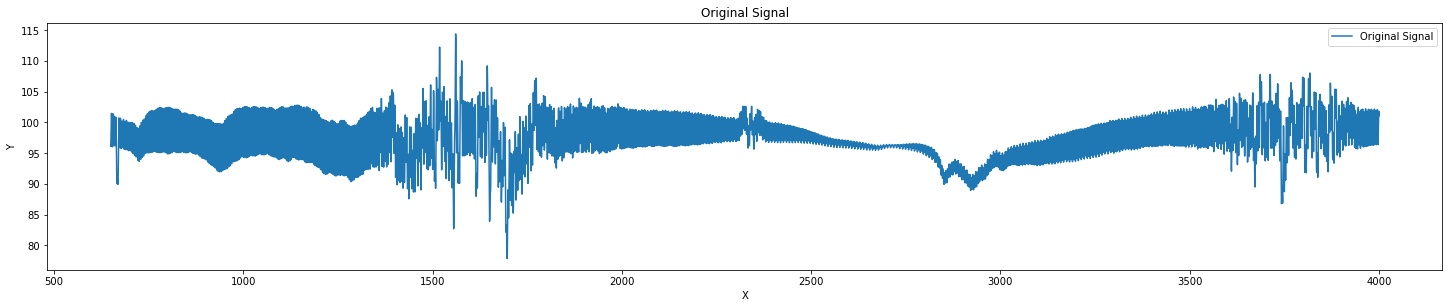

In [122]:
# Plot the original signal
plt.figure(figsize=(25, 10))
plt.subplot(2, 1, 1)
plt.plot(x, y, label='Original Signal')
plt.title('Original Signal')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()

In [123]:
# Apply FFT to the signal
yf = fft(y)
N = len(y)
freqs = np.fft.fftfreq(N, d=(x[1] - x[0]))

In [124]:
# Denoising: Zero out high-frequency components
threshold = 0.1 * np.max(np.abs(freqs))  # Adjust this threshold based on the signal
yf[np.abs(freqs) > threshold] = 0

In [125]:
# Apply inverse FFT to get the denoised signal
y_denoised = ifft(yf).real  # Take the real part of the inverse FFT result

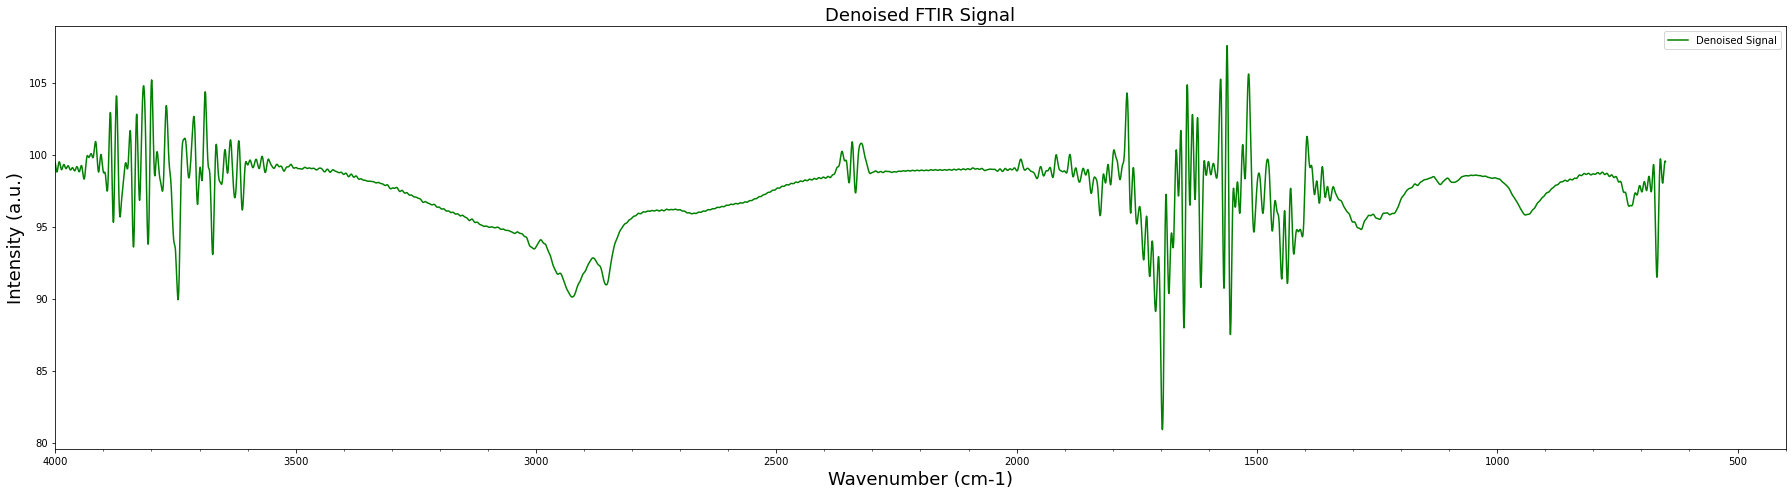

In [126]:
# Plot the denoised signal
plt.figure(figsize=(25, 13))
plt.subplot(2, 1, 2)
plt.plot(x, y_denoised, label='Denoised Signal', color='green')
plt.title('Denoised FTIR Signal', fontsize=18)
plt.xlabel('Wavenumber (cm-1)', fontsize=18)
plt.ylabel('Intensity (a.u.)', fontsize=18)
plt.gca().invert_xaxis()  # Reverse the x-axis
plt.xlim(4000, 400)  # Set x-axis limits to exclude extra space

# Add minor tick marks
ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(500))  # Major ticks every 500
ax.xaxis.set_minor_locator(MultipleLocator(100))  # Minor ticks every 100

plt.legend()

# Construct the filename for saving the plot
base_name = os.path.splitext(os.path.basename(csv_filename))[0]
plot_filename = f"denoised_plot_{base_name}.jpg"
csv_output_filename = f"denoised_data_{base_name}.csv"

# Save the plot as a JPEG image
plt.savefig(plot_filename, format='jpg', pil_kwargs={'quality': 95}, bbox_inches='tight')

plt.tight_layout()
plt.show()

In [127]:
# Export the denoised data to a new CSV file
denoised_data = pd.DataFrame({'X': x, 'Y_Denoised': y_denoised})
denoised_data.to_csv(csv_output_filename, index=False)

print(f"Denoised data saved to '{csv_output_filename}'")
print(f"Plot saved as '{plot_filename}'")

Denoised data saved to 'denoised_data_JCP 2_27.csv'
Plot saved as 'denoised_plot_JCP 2_27.jpg'


<Figure size 432x288 with 0 Axes>